In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Installer yfinance : pip install yfinance
# Mettre à jour : pip install -U yfinance

In [2]:
data = yf.download("NTDOY", period="10y")

C:\Users\raphe\AppData\Local\Temp\ipykernel_19924\2011318020.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("NTDOY", period="10y")
[*********************100%***********************]  1 of 1 completed


In [22]:
data["Close"].to_csv("data/nintendo_10y.csv")

In [23]:
df = pd.read_csv("data/nintendo_10y.csv")

print(df.head())

         Date     NTDOY
0  2015-09-16  4.481522
1  2015-09-17  4.325488
2  2015-09-18  4.252409
3  2015-09-21  4.295862
4  2015-09-22  4.228708


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

nb_nan = df.isna().sum()
print("NaN values are :")
print(nb_nan)

NaN values are :
Date     0
NTDOY    0
dtype: int64


In [33]:
# returns and log returns

df_returns = pd.DataFrame()
df_returns["Date"] = pd.to_datetime(df["Date"])
df_returns["returns"] = df["NTDOY"].pct_change()
df_returns["log_returns"] = np.log(df["NTDOY"] / df["NTDOY"].shift(1))

df_returns.head()

,Date,returns,log_returns
0,2015-09-16,NaN,NaN
1,2015-09-17,-0.034817,-0.035438
2,2015-09-18,-0.016895,-0.017039
3,2015-09-21,0.010218,0.010166
4,2015-09-22,-0.015632,-0.015756


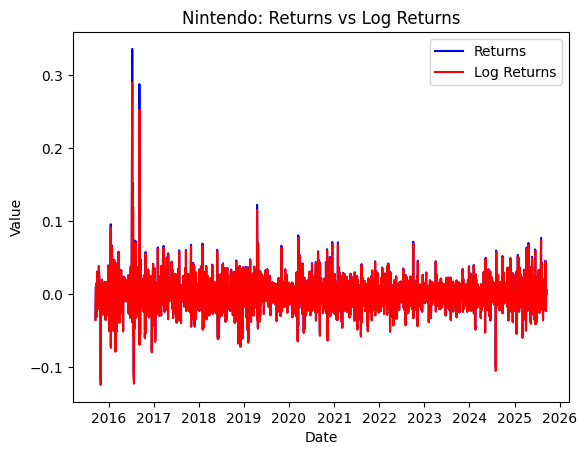

In [34]:
# plot

plt.plot(df_returns["Date"], df_returns["returns"], label="Returns", color="blue")
plt.plot(df_returns["Date"], df_returns["log_returns"], label="Log Returns", color="red")
plt.legend()
plt.title("Nintendo: Returns vs Log Returns")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()

Number of outliers in returns: 105, for a total of 2515 data points.


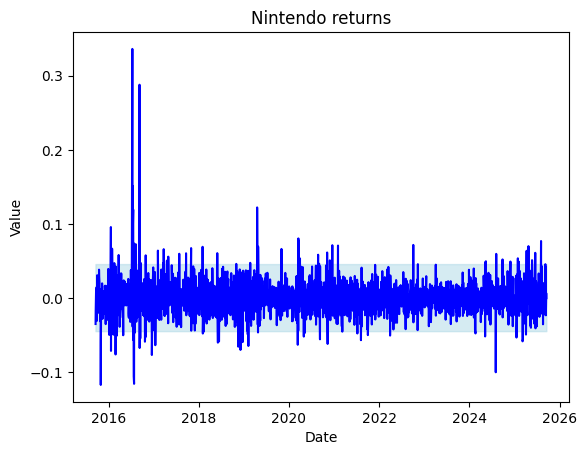

In [36]:
Q1 = df_returns["returns"].quantile(0.25)
Q3 = df_returns["returns"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_returns[(df_returns["returns"] < lower_bound) | (df_returns["returns"] > upper_bound)]
nb_outliers = outliers.shape[0]
print(f"Number of outliers in returns: {nb_outliers}, for a total of {df_returns.shape[0]} data points.")

#plot the bound
plt.plot(df_returns["Date"], df_returns["returns"], color="blue")
plt.fill_between(df_returns["Date"], lower_bound, upper_bound, color="lightblue", alpha=0.5)
plt.title("Nintendo returns")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()

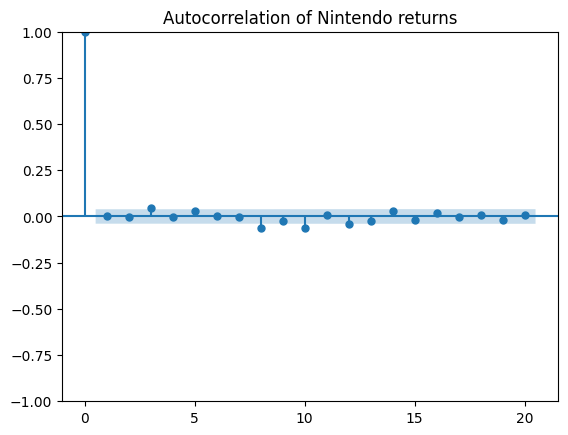

In [38]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df_returns["returns"].dropna(), lags=20) # lags = number of lags to show
plt.title("Autocorrelation of Nintendo returns")
plt.show()

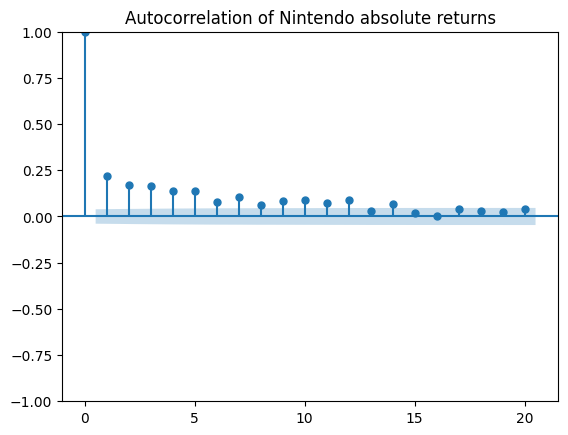

In [40]:
df_returns["abs_returns"] = df_returns["returns"].abs()
plot_acf(df_returns["abs_returns"].dropna(), lags=20)
plt.title("Autocorrelation of Nintendo absolute returns")
plt.show()

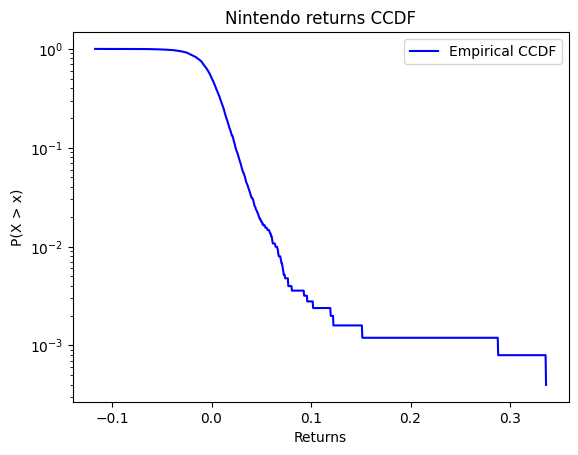

<Figure size 640x480 with 0 Axes>

In [48]:
import statsmodels
from statsmodels.distributions.empirical_distribution import ECDF

ecdf = ECDF(df_returns["returns"])
x_axis = np.linspace(df_returns["returns"].min(), df_returns["returns"].max(), num=1000)
P_gt = 1 - ecdf(x_axis)

plt.plot(x_axis, P_gt, label="Empirical CCDF", color="blue")
plt.yscale("log")
plt.title("Nintendo returns CCDF")
plt.xlabel("Returns")
plt.ylabel("P(X > x)")
plt.legend()
plt.show()
plt.savefig("plot/nintendo_returns_ccdf.pdf")

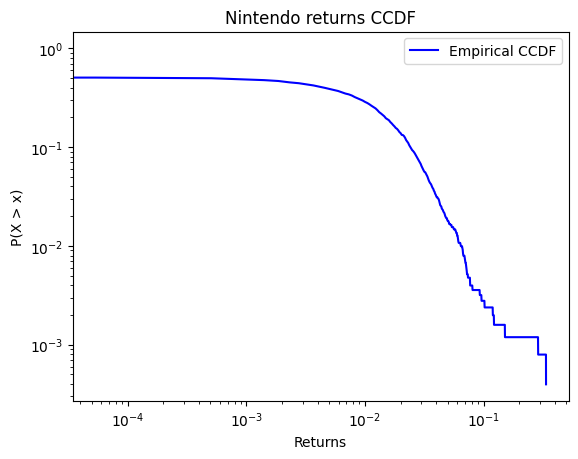

<Figure size 640x480 with 0 Axes>

In [50]:
plt.plot(x_axis, P_gt, label="Empirical CCDF", color="blue")
plt.yscale("log")
plt.xscale("log")
plt.title("Nintendo returns CCDF")
plt.xlabel("Returns")
plt.ylabel("P(X > x)")
plt.legend()
plt.show()
plt.savefig("plot/nintendo_returns_ccdf_log_log.pdf")